In [1]:
!rm -rf /kaggle/working/hack-mfti
!git config --global credential.helper store
!echo "МОЙ ТОКЕН ГИТХАБА)" > ~/.git-credentials
!git clone -b case/sber --single-branch https://github.com/be1pheg0r/hack-mfti.git
!git -C /kaggle/working/hack-mfti log -1 --oneline

import sys
sys.path.insert(0, "/kaggle/working/hack-mfti")

!pip install -q -r hack-mfti/requirements.txt
!pip install -q -r hack-mfti/requirements-dev.txt

Cloning into 'hack-mfti'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 264 (delta 72), reused 82 (delta 63), pack-reused 164 (from 1)
Receiving objects: 100% (264/264), 7.77 MiB | 15.09 MiB/s, done.
Resolving deltas: 100% (147/147), done.
83875dd (HEAD -> case/sber, origin/case/sber) [sber/data] Добавил датасет чтобы перекинуть на кеглю
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 91.5 kB/s eta 0:00:0000:0100:02m


In [2]:
from common.paths import get_sber_gitignore_data_dpath, get_sber_data_dpath, get_sber_checkpoints_dpath
from common.logger import JUPYTER_LOGGER as logger

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [3]:
features_fpath = get_sber_data_dpath() / "features_with_judge_scores.csv"
test_fpath = get_sber_data_dpath() / "knowledge_bench_public.csv"
train_df = pd.read_csv(features_fpath)
train_df = train_df.dropna(subset=["ground_truth", "model_answer", "is_hallucination"]).reset_index(drop=True)
train_df["is_hallucination"] = train_df["is_hallucination"].astype(int)

val_df = pd.read_csv(test_fpath)
val_df = val_df.dropna(subset=["correct_answer", "model_answer", "is_hallucination"]).reset_index(drop=True)
val_df["is_hallucination"] = val_df["is_hallucination"].astype(int)
val_df = val_df.rename(columns={"correct_answer": "ground_truth"})

logger.info(train_df.shape)
logger.info(test_df.shape)
train_df.head(2)

2026-04-03 15:30:07,771 - jupyter-notebooks - INFO - [JUPYTER 📓] (1391, 1622)


,sample_id,query,ground_truth,model_answer,temperature,hallucination_score,is_hallucination,feature_0,feature_1,feature_2,...,feature_1605,feature_1606,feature_1607,feature_1608,feature_1609,feature_1610,feature_1611,feature_1612,judge_prompt,judge_score
0,0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1.049065,41.666667,1,-2.184582,-16.949598,-0.000303,...,0.028273,0.019163,0.029646,0.015739,0.073697,0.044748,0.5,0.0,"\nТы — судья, оценивающий точность ответа моде...",True
1,1,"Где родился создатель музыки к фильму ""Крадено...",Каламата,Создателем музыки к фильму «Краденое небо» явл...,1.049065,37.500000,1,-2.548452,-17.273001,-0.000017,...,0.027378,0.014426,0.033654,0.019120,0.075012,0.035969,0.5,0.0,"\nТы — судья, оценивающий точность ответа моде...",True


In [39]:
model_name = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, device_map="auto")
model.eval()

def predict_nli(premise: str, hypothesis: str) -> dict:
    inputs = tokenizer(premise, hypothesis, truncation=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits[0], dim=-1).tolist()
    labels = ["entailment", "neutral", "contradiction"]
    return dict(zip(labels, probs))

# hallucination = contradiction или neutral (не entailment)
# False = нет галлюцинации, True = галлюцинация
def is_hallucination(premise: str, hypothesis: str, threshold: float = 0.5) -> bool:
    scores = predict_nli(premise, hypothesis)
    return scores["entailment"] < threshold

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Валидация по датасету
# premise = ground_truth (контекст/эталон), hypothesis = model_answer
val_df = features_df.dropna(subset=["ground_truth", "model_answer", "is_hallucination"]).copy()
logger.info(f"Validation samples: {len(val_df)}")
logger.info(val_df["is_hallucination"].value_counts())

Validation samples: 1391
is_hallucination
1    1091
0     300
Name: count, dtype: int64


In [41]:
from tqdm.auto import tqdm

THRESHOLD = 0.5

preds = []
for _, row in tqdm(val_df.iterrows(), total=len(val_df)):
    pred = is_hallucination(row["ground_truth"], row["model_answer"], threshold=THRESHOLD)
    preds.append(pred)

val_df["pred_is_hallucination"] = preds
val_df[["ground_truth", "model_answer", "is_hallucination", "pred_is_hallucination"]].head(5)

  0%|          | 0/1391 [00:00<?, ?it/s]

,ground_truth,model_answer,is_hallucination,pred_is_hallucination
0,Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1,True
1,Каламата,Создателем музыки к фильму «Краденое небо» явл...,1,True
2,Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,1,True
3,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",1,False
4,"Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \n\nШтоф — это небольшая б...,1,False


                          precision    recall  f1-score   support

False (no hallucination)       0.24      0.34      0.28       300
    True (hallucination)       0.80      0.70      0.75      1091

                accuracy                           0.63      1391
               macro avg       0.52      0.52      0.52      1391
            weighted avg       0.68      0.63      0.65      1391



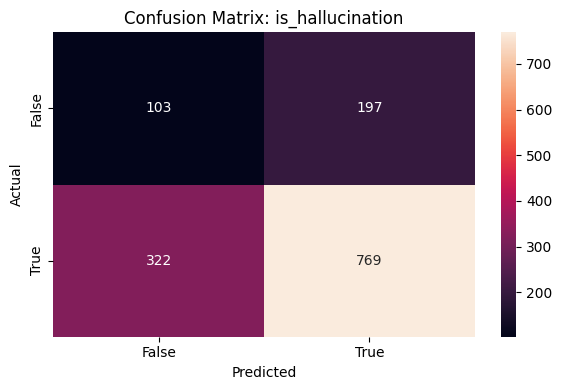

In [42]:
y_true = val_df["is_hallucination"].astype(bool)
y_pred = val_df["pred_is_hallucination"].astype(bool)

logger.info(classification_report(y_true, y_pred, target_names=["False (no hallucination)", "True (hallucination)"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["False", "True"], yticklabels=["False", "True"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: is_hallucination")
plt.tight_layout()
plt.show()

scoring:   0%|          | 0/1391 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Best threshold: 0.6908, AP: 0.5637


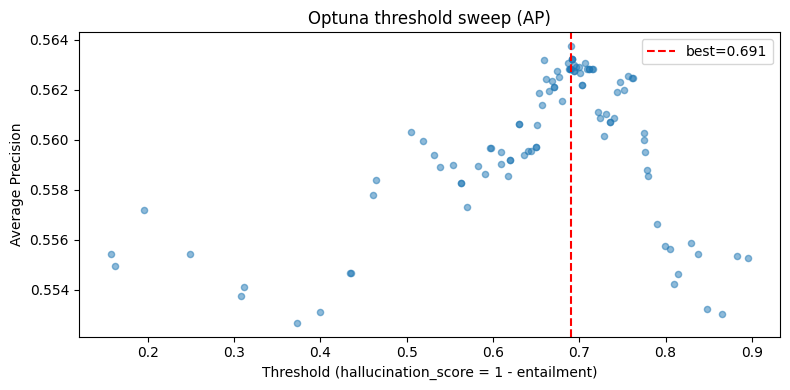

In [47]:
import optuna
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

all_scores = []
for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="scoring"):
    s = predict_nli(row["ground_truth"], row["model_answer"])
    all_scores.append(s["entailment"])

entailment_scores = np.array(all_scores)
# галлюцинация = низкий entailment → инвертируем для AP
hallucination_scores = 1 - entailment_scores

def objective(trial):
    threshold = trial.suggest_float("threshold", 0.1, 0.9)
    preds = (hallucination_scores > threshold).astype(int)
    return average_precision_score(y_true.astype(int), preds, sample_weight=sample_weights)

class_weight = {0: 3.0, 1: 1.0}
sample_weights = y_true.astype(int).map(class_weight).values

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

best_t = study.best_params["threshold"]
best_ap = study.best_value
logger.info(f"Best threshold: {best_t:.4f}, AP: {best_ap:.4f}")

# plot
trial_df = study.trials_dataframe()
plt.figure(figsize=(8, 4))
plt.scatter(trial_df["params_threshold"], trial_df["value"], alpha=0.5, s=20)
plt.axvline(best_t, color="r", linestyle="--", label=f"best={best_t:.3f}")
plt.xlabel("Threshold (hallucination_score = 1 - entailment)")
plt.ylabel("Average Precision")
plt.title("Optuna threshold sweep (AP)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
MODEL_NAME = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
MAX_LEN    = 512
BATCH_SIZE = 8
EPOCHS     = 5
LR         = 3e-5
SEED       = 42
DTYPE = torch.float32

torch.manual_seed(SEED)
np.random.seed(SEED)

In [21]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup


class HallucinationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df        = df
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            row["ground_truth"],
            row["model_answer"],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        label = torch.tensor(row["is_hallucination"], dtype=torch.long)
        return {k: v.squeeze(0) for k, v in enc.items()}, label

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader = DataLoader(HallucinationDataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HallucinationDataset(val_df,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
    dtype=DTYPE,
).to(device)

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2).to(device=device, dtype=DTYPE)

with torch.no_grad():
    nn.init.xavier_uniform_(model.classifier.weight)
    nn.init.zeros_(model.classifier.bias)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * len(train_loader) * EPOCHS),
    num_training_steps=len(train_loader) * EPOCHS,
)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([3.0, 1.0], device=device, dtype=DTYPE)
)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
deberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.bias                 | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight               | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [24]:
model.eval()
batch, labels = next(iter(train_loader))
batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad(), torch.autocast(device_type="cuda", dtype=DTYPE):
    print(model(**batch).logits[:3])

tensor([[ 0.2586, -0.3046],
        [ 0.2136, -0.0879],
        [-0.1188,  0.7667]], device='cuda:0')


In [25]:
def evaluate(model, loader):
    model.eval()

    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for batch, labels in tqdm(loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(**batch).logits

            probs = torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=-1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    y_true  = np.array(all_labels)
    y_pred  = np.array(all_preds)
    y_probs = np.array(all_probs)

    if np.any(~np.isfinite(y_probs)):
        y_probs = np.nan_to_num(y_probs, nan=0.5)

    sw = np.where(y_true == 1,
                  (1 - y_true.mean()) / y_true.mean(),
                  1.0)

    ap = average_precision_score(y_true, y_probs, sample_weight=sw)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    return ap, f1, y_true, y_pred

In [ ]:
best_ap = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)
    
        optimizer.zero_grad(set_to_none=True)
    
        with torch.autocast(device_type="cuda", dtype=DTYPE):
            logits = model(**batch).logits
            loss = criterion(logits, labels)
    
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    ap, f1, _, _ = evaluate(model, val_loader)
    logger.info(f"Epoch {epoch} | loss={total_loss / len(train_loader):.4f} | weighted AP={ap:.4f} | F1={f1:.4f}")
    if ap > best_ap:
        best_ap = ap
        torch.save(model.state_dict(), "best_hallucination_model.pt")
        logger.info("  → saved")

Epoch 1:   0%|          | 0/174 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac85548ac00>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ac85548ac00>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()self._shutdown_workers()

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

         if w.is_alive(): 
  ^^  ^ ^ ^^ ^ ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^ ^
   File "/usr/lib/pyth

Epoch 2:   0%|          | 0/174 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

...

Epoch 4:   0%|          | 0/174 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

2026-04-03 16:06:04,652 - jupyter-notebooks - INFO - [JUPYTER 📓] Epoch 4 | loss=0.0799 | weighted AP=0.9258 | F1=0.8758


Epoch 5:   0%|          | 0/174 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

In [27]:
from huggingface_hub import login
login(token="МОЙ ТОКЕН ХФ)")

repo_name = "be1pheg0r/hack-mfti-sbercase"
model.load_state_dict(torch.load("best_hallucination_model.pt"))
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/be1pheg0r/hack-mfti-sbercase/commit/633bc36a4be173a091dd900aceecf45aadf9e8c7', commit_message='Upload tokenizer', commit_description='', oid='633bc36a4be173a091dd900aceecf45aadf9e8c7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/be1pheg0r/hack-mfti-sbercase', endpoint='https://huggingface.co', repo_type='model', repo_id='be1pheg0r/hack-mfti-sbercase'), pr_revision=None, pr_num=None)

In [28]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(repo_name)

model = AutoModelForSequenceClassification.from_pretrained(
    repo_name,
    torch_dtype=torch.bfloat16,
).to(device)

config.json:   0%|          | 0.00/922 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [29]:
train_loader = DataLoader(HallucinationDataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HallucinationDataset(val_df,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

evaluate(model, val_loader)

  0%|          | 0/131 [00:00<?, ?it/s]

(np.float64(0.9444696324467907),
 0.9020979020979021,
 array([0, 0, 1, ..., 0, 1, 1]),
 array([1, 0, 1, ..., 0, 0, 1]))